In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hummaamqaasim/jobs-in-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\hummaamqaasim\jobs-in-data\versions\6


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
#Load the dataset
df = pd.read_csv('jobs_in_data.csv')

#For this analysis, we consider only companies located in the United States.
df_US = df[df['company_location'] == 'United States']
df_US.head()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M
5,2023,Data Scientist,Data Science and Research,USD,130000,130000,United States,Senior,Full-time,Remote,United States,M


In [24]:
#Getting initial insights in our data.
df_US.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8132 entries, 1 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           8132 non-null   int64 
 1   job_title           8132 non-null   object
 2   job_category        8132 non-null   object
 3   salary_currency     8132 non-null   object
 4   salary              8132 non-null   int64 
 5   salary_in_usd       8132 non-null   int64 
 6   employee_residence  8132 non-null   object
 7   experience_level    8132 non-null   object
 8   employment_type     8132 non-null   object
 9   work_setting        8132 non-null   object
 10  company_location    8132 non-null   object
 11  company_size        8132 non-null   object
dtypes: int64(3), object(9)
memory usage: 825.9+ KB


In [25]:
#Get the top 3 data job categories in the United States
df_US['job_category'].value_counts().head(3)

#Save the top 3 data job categories to a variable
top_3_job = df_US['job_category'].value_counts().head(3).index.to_list()

In [26]:
#Limit the data to top 3 data jobs only:
df_US_top3 = df_US[df_US['job_category'].isin(top_3_job)]
df_US_top3

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M
5,2023,Data Scientist,Data Science and Research,USD,130000,130000,United States,Senior,Full-time,Remote,United States,M
6,2023,Data Scientist,Data Science and Research,USD,100000,100000,United States,Senior,Full-time,Remote,United States,M
9,2023,Data Engineer,Data Engineering,USD,210000,210000,United States,Executive,Full-time,Remote,United States,M
...,...,...,...,...,...,...,...,...,...,...,...,...
9344,2020,Data Engineer,Data Engineering,USD,130800,130800,Spain,Mid-level,Full-time,Remote,United States,M
9351,2020,Data Scientist,Data Science and Research,USD,412000,412000,United States,Senior,Full-time,Remote,United States,L
9352,2021,Principal Data Scientist,Data Science and Research,USD,151000,151000,United States,Mid-level,Full-time,Remote,United States,L
9353,2020,Data Scientist,Data Science and Research,USD,105000,105000,United States,Entry-level,Full-time,Remote,United States,S


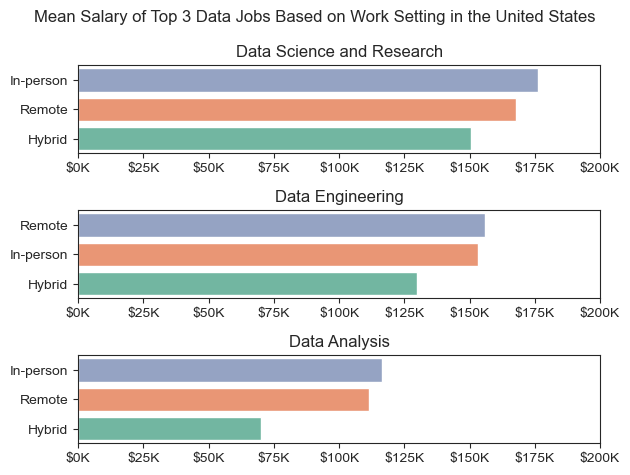

In [27]:
#1.) Mean salary of the Top 3 Data Job Categories on Different Work Settings

mean_work_setting = df_US_top3.groupby(['job_category', 'work_setting'])['salary_in_usd'].mean()
mean_work_setting = mean_work_setting.reset_index(name='mean_salary')
mean_work_setting = mean_work_setting.sort_values(by='mean_salary', ascending=False)
fig, ax = plt.subplots(3,1)
sns.set_style(style='ticks')
for i,job in enumerate(top_3_job):
    mean_work_setting_plot = mean_work_setting[mean_work_setting['job_category'] == job]
    sns.barplot(data=mean_work_setting_plot, y='work_setting', x='mean_salary', legend=False, ax=ax[i], palette='Set2', hue='mean_salary')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,200000)
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.suptitle('Mean Salary of Top 3 Data Jobs Based on Work Setting in the United States')
plt.tight_layout()
plt.show()

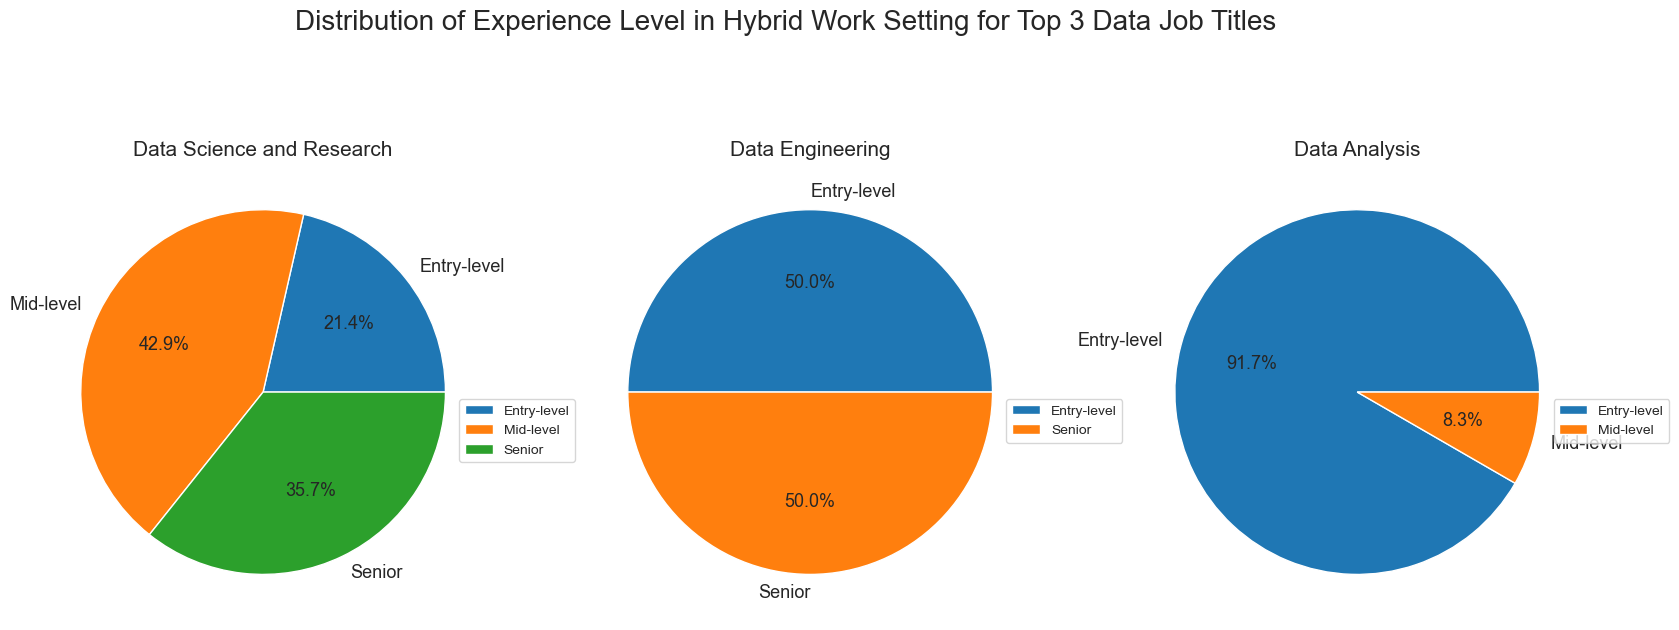

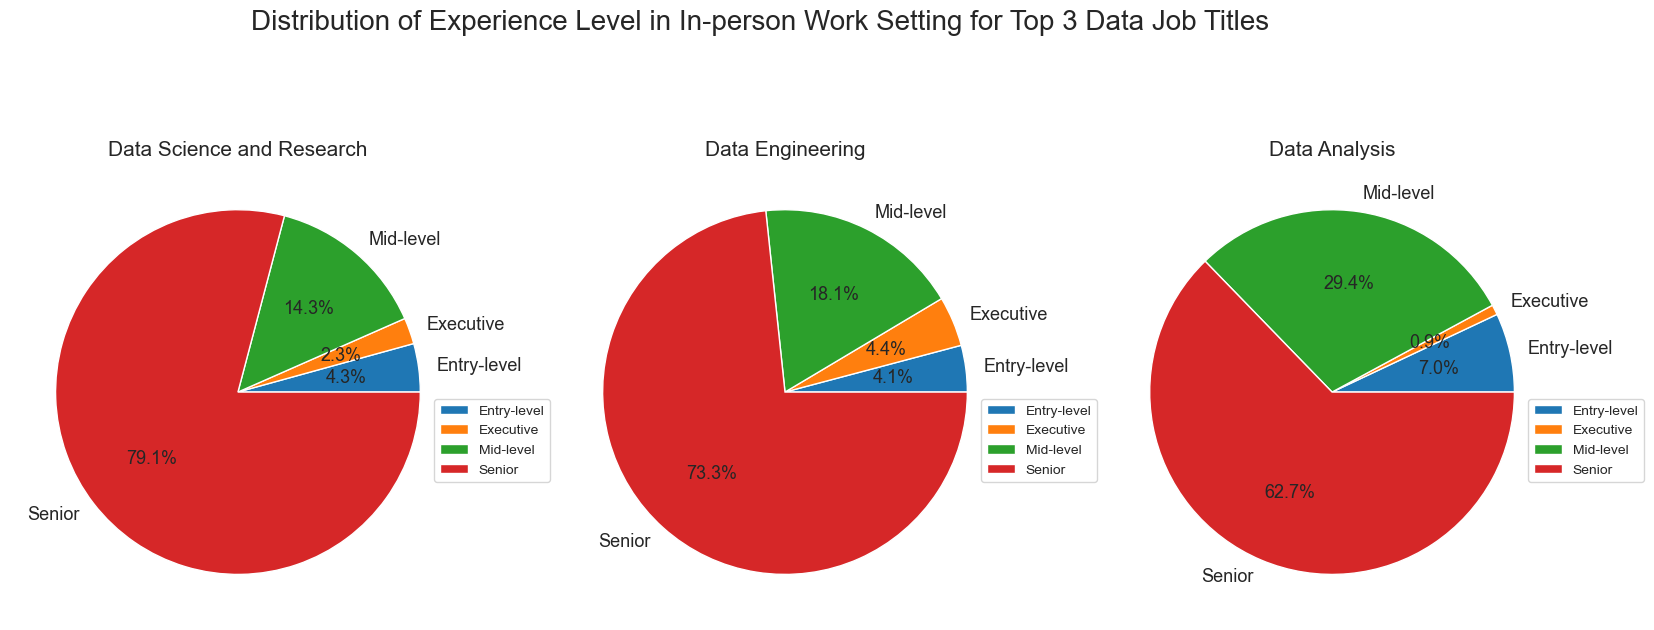

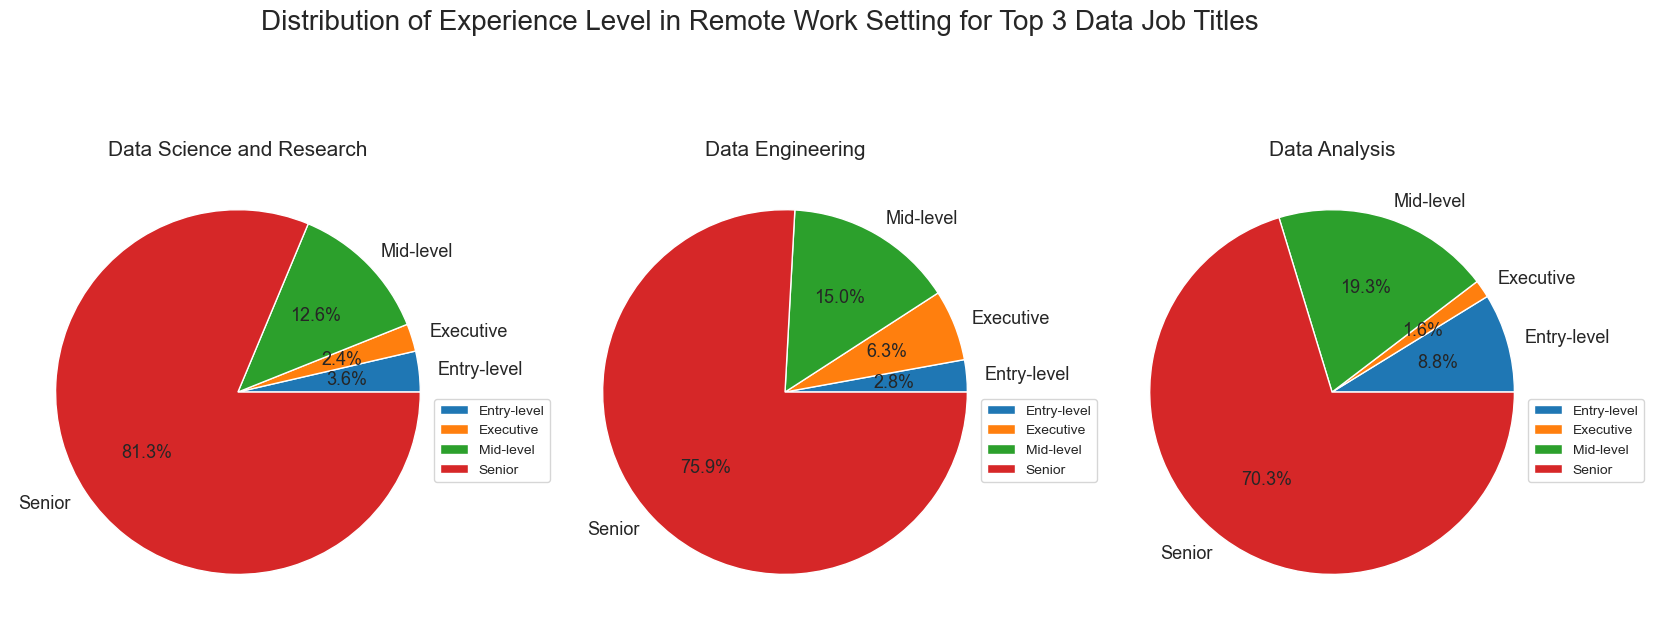

In [28]:
#Deep dive on to what causing why Hybrid work setting mean salary to be the lowest
df_US_distribution = df_US_top3.groupby(['job_category', 'work_setting', 'experience_level'],dropna=False).size()
df_US_distribution = df_US_distribution.reset_index(name='job_count')
df_US_distribution = df_US_distribution[df_US_distribution['job_category'].isin(top_3_job)]
setting_work = ['Hybrid', 'In-person', 'Remote']
for work in setting_work:
    df_US_dist_plot = df_US_distribution[df_US_distribution['work_setting'] == work]
    df_US_dist_plot = df_US_dist_plot.set_index('job_category')

    fig,ax = plt.subplots(1,3, figsize=(20,15))
    for i,job in enumerate(top_3_job):
        ax[i].pie(data=df_US_dist_plot.loc[job], x='job_count', labels=df_US_dist_plot.loc[job]['experience_level'], autopct='%1.1f%%', textprops={'fontsize': 13})
        ax[i].set_title(job, fontsize=15)
        ax[i].legend(loc='upper right', bbox_to_anchor=(1.2,0.5))
    plt.suptitle(f'Distribution of Experience Level in {work} Work Setting for Top 3 Data Job Titles', y=0.75, fontsize=20)

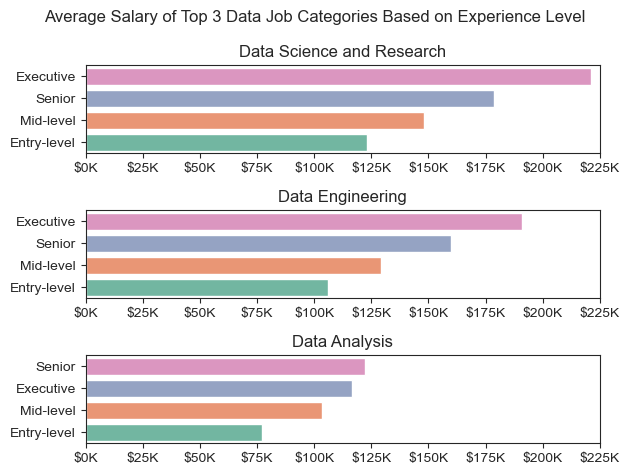

In [29]:
#2.) Mean salary for top 3 data job categories based on experience level
mean_exp_level = df_US_top3.groupby(['job_category', 'experience_level'])['salary_in_usd'].mean()
mean_exp_level = mean_exp_level.reset_index(name='mean_salary')
mean_exp_level = mean_exp_level.sort_values(by='mean_salary', ascending=False)
fig, ax = plt.subplots(3,1)
sns.set_style(style='ticks')
for i,job in enumerate(top_3_job):
    mean_exp_level_plot = mean_exp_level[mean_exp_level['job_category'] == job]
    sns.barplot(data=mean_exp_level_plot, y='experience_level', x='mean_salary', legend=False, ax=ax[i], palette='Set2', hue='mean_salary')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,225000)
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.suptitle('Average Salary of Top 3 Data Job Categories Based on Experience Level')
plt.tight_layout()
plt.show()

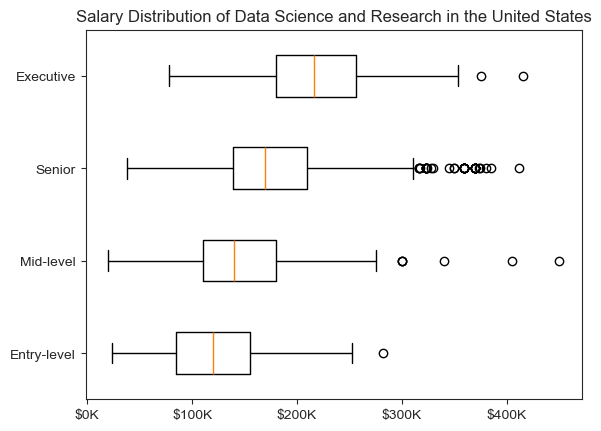

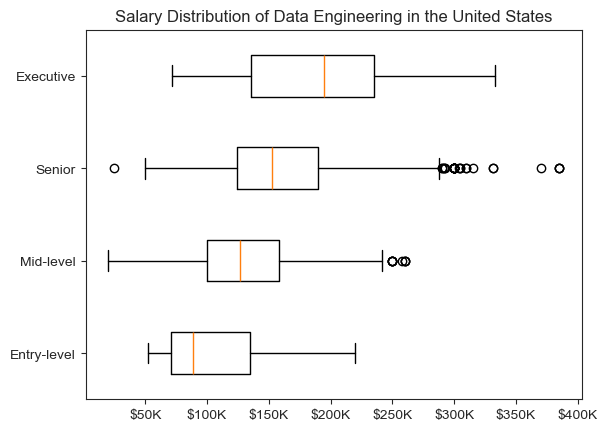

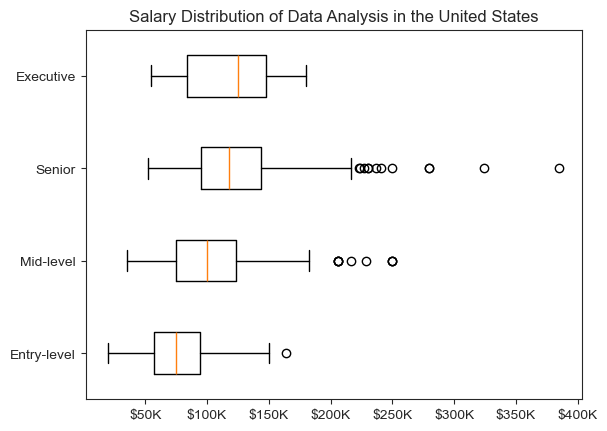

In [30]:
#Are these categories paid well?
experience = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
sns.set_style('ticks')
for job in top_3_job:
    df_US_DA = df_US_top3[df_US_top3['job_category'] == job]
    DA_list = [df_US_DA[df_US_DA['experience_level'] == exp]['salary_in_usd'] for exp in experience]
    plt.boxplot(DA_list, tick_labels=experience, vert=False)
    plt.title(f'Salary Distribution of {job} in the United States')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
    plt.show()